In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import csv

## Setup:
We will be working with 100 SKUs, 1 store setup. This is because our data only support 1 layer of store, and we limit the number of SKUs to 100 to keep things simple.

The original code runs on data of about 3 years. We will use 3 year for our case.

## Data preparation:

Looking at the `sku100.single_store.standard.yml` file, we need to transform the Walmart data into the same template with these files:
- sku_list: ReplenishmentEnv/data/sku2778/sku100.sku_list.csv
- procurement_cost: ReplenishmentEnv/data/sku2778/sku2778.store2.selling_price.csv
- selling_price: ReplenishmentEnv/data/sku2778/sku2778.store1.selling_price.csv
- demand: ReplenishmentEnv/data/sku2778/sku2778.demand.csv
- static_data: ReplenishmentEnv/data/sku2778/sku2778.store1.info.csv

### SKU list
Looking at the raw demand data, we can see that it's very dense - there are demands for almost every day. But the Walmart data is rather sparse - there are many days with demand = 0.

When exploring the Walmart file in Excel, I realized `store = CA_3` and `cat_id = FOODS` has most dense demand. Therefore that's what we're going to work with.

To further narrow down the SKU list, the code below looks for SKUs with no periods of 7 days without any demand.

In [ ]:
df = pd.read_csv("sales_train_evaluation.csv")

In [ ]:
store = 'CA_2'

ca2_df = df.query('store_id == @store')

ca2_df

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
3049,HOBBIES_1_001_CA_2_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_2,CA,0,0,0,0,...,2,0,2,0,2,2,0,2,0,1
3050,HOBBIES_1_002_CA_2_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_2,CA,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
3051,HOBBIES_1_003_CA_2_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_2,CA,0,0,0,0,...,1,1,0,1,1,0,0,1,0,2
3052,HOBBIES_1_004_CA_2_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_2,CA,6,3,2,8,...,0,3,8,1,3,1,1,3,6,2
3053,HOBBIES_1_005_CA_2_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_2,CA,0,0,0,0,...,1,3,2,1,3,2,0,3,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6093,FOODS_3_823_CA_2_evaluation,FOODS_3_823,FOODS_3,FOODS,CA_2,CA,0,0,0,0,...,2,4,2,2,0,1,2,7,3,2
6094,FOODS_3_824_CA_2_evaluation,FOODS_3_824,FOODS_3,FOODS,CA_2,CA,2,0,0,0,...,1,2,2,0,1,1,1,1,0,0
6095,FOODS_3_825_CA_2_evaluation,FOODS_3_825,FOODS_3,FOODS,CA_2,CA,1,0,1,0,...,0,0,3,1,1,1,1,3,2,3
6096,FOODS_3_826_CA_2_evaluation,FOODS_3_826,FOODS_3,FOODS,CA_2,CA,0,0,0,0,...,0,1,0,0,5,1,0,2,3,2


In [58]:
# Define 3-year window (approx 3*365 = 1095 days)
max_gap = 14
max_cnt = 0
best_start = None
best_consistent_items = []

for start_day in range(1, 1941 - 1095):
    end_day = start_day + 1095  # define end of 3-year window

    # Extract relevant day columns
    day_cols = [f'd_{i}' for i in range(start_day, end_day + 1)]
    window_df = ca2_df[['id'] + day_cols]

    # Check for long inactive gaps (7 consecutive zero days, updated rolling syntax)
    zero_matrix = (window_df[day_cols] == 0).astype(int)
    rolling_zero = zero_matrix.T.rolling(window=max_gap).sum().T
    long_gap = (rolling_zero == max_gap).any(axis=1)

    # Filter consistent items
    consistent_items = window_df[~long_gap]['id'].unique()

    if len(consistent_items) > max_cnt:
        max_cnt = len(consistent_items)
        best_start = start_day
        best_consistent_items = consistent_items[:]

print(f"Best window starts at d_{best_start}, with {max_cnt} continuous items.")

Best window starts at d_834, with 271 continuous items.


Looking at the `calendar.csv` file, `d_836` corresponds to `2013-05-13`.

Our end date is `d_836` + 1095 days, which is `d_1931`, or `2016-05-12`. 

In [60]:
# Write the output to a file
best_consistent_items = best_consistent_items[:100] # this step is not needed since we have exactly 100 SKUs, I just put it here for clarity

with open('../processed/wm2/sku100.sku_list.ca2.highest_demand.csv', 'w') as file:
    writer = csv.writer(file)
    writer.writerow(['SKU'])
    for item in best_consistent_items:
        writer.writerow([item])

### Procurement cost and selling price

We have selling price data from Walmart, but we don't have procurement cost. We will make the assumption that procurement cost is 70% of selling price.

Now we need to transform the weekly sales price from `sell_prices.csv` to the same format as `sku2778.store2.selling_price.csv`, and to get the procurement cost we apply a 70% reduction.

In [61]:
wm_price = pd.read_csv('sell_prices.csv')
wm_price

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26
...,...,...,...,...
6841116,WI_3,FOODS_3_827,11617,1.00
6841117,WI_3,FOODS_3_827,11618,1.00
6841118,WI_3,FOODS_3_827,11619,1.00
6841119,WI_3,FOODS_3_827,11620,1.00


In [62]:
calendar = pd.read_csv('calendar.csv')
calendar

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1964,2016-06-15,11620,Wednesday,5,6,2016,d_1965,NaN,NaN,NaN,NaN,0,1,1
1965,2016-06-16,11620,Thursday,6,6,2016,d_1966,NaN,NaN,NaN,NaN,0,0,0
1966,2016-06-17,11620,Friday,7,6,2016,d_1967,NaN,NaN,NaN,NaN,0,0,0
1967,2016-06-18,11621,Saturday,1,6,2016,d_1968,NaN,NaN,NaN,NaN,0,0,0


In [63]:
best_consistent_item_ids = [x.split('_CA_')[0] for x in best_consistent_items]

In [64]:
items = best_consistent_item_ids
start_d, end_d = 'd_836', 'd_1931'

start_d_num = int(start_d.split('_')[1])
end_d_num = int(end_d.split('_')[1])

calendar['d_num'] = calendar['d'].str.split('_').str[1].astype(int)

cal = calendar.loc[
    (calendar['d_num'] >= start_d_num) & (calendar['d_num'] <= end_d_num),
    ['date', 'wm_yr_wk', 'd']
].copy()

cal['Date'] = pd.to_datetime(cal['date']).dt.strftime('%Y/%m/%d')

wm = wm_price.query("store_id == @store and item_id in @items")[['item_id', 'wm_yr_wk', 'sell_price']]

cal['wm_yr_wk'] = cal['wm_yr_wk'].astype(int)
wm['wm_yr_wk'] = wm['wm_yr_wk'].astype(int)
daily = cal.merge(wm, on='wm_yr_wk', how='left')

wide = (
    daily.pivot_table(index='Date', columns='item_id', values='sell_price', aggfunc='first')
    .sort_index()
)

cols = [c for c in items if c in wide.columns]
wide = wide[cols]

selling_price = wide.reset_index()
selling_price.columns = ['Date'] + [x + f'_{store}_evaluation' for x in selling_price.columns[1:]]

procurement_cost = selling_price.copy()

# Set the price to be 70% of current values
procurement_cost.iloc[:, 1:] = procurement_cost.iloc[:, 1:] * 0.7

procurement_cost

,Date,HOBBIES_1_004_CA_2_evaluation,HOBBIES_1_008_CA_2_evaluation,HOBBIES_1_014_CA_2_evaluation,HOBBIES_1_015_CA_2_evaluation,HOBBIES_1_016_CA_2_evaluation,HOBBIES_1_021_CA_2_evaluation,HOBBIES_1_043_CA_2_evaluation,HOBBIES_1_048_CA_2_evaluation,HOBBIES_1_079_CA_2_evaluation,...,HOUSEHOLD_1_235_CA_2_evaluation,HOUSEHOLD_1_238_CA_2_evaluation,HOUSEHOLD_1_241_CA_2_evaluation,HOUSEHOLD_1_243_CA_2_evaluation,HOUSEHOLD_1_247_CA_2_evaluation,HOUSEHOLD_1_249_CA_2_evaluation,HOUSEHOLD_1_262_CA_2_evaluation,HOUSEHOLD_1_268_CA_2_evaluation,HOUSEHOLD_1_275_CA_2_evaluation,HOUSEHOLD_1_280_CA_2_evaluation
0,2013/05/13,3.248,0.322,0.686,0.504,0.504,8.316,0.504,0.322,5.516,...,2.429,1.736,5.558,1.379,0.679,5.579,0.679,5.859,2.079,3.479
1,2013/05/14,3.248,0.322,0.686,0.504,0.504,8.316,0.504,0.322,5.516,...,2.429,1.736,5.558,1.379,0.679,5.579,0.679,5.859,2.079,3.479
2,2013/05/15,3.248,0.322,0.686,0.504,0.504,8.316,0.504,0.322,5.516,...,2.429,1.736,5.558,1.379,0.679,5.579,0.679,5.859,2.079,3.479
3,2013/05/16,3.248,0.322,0.686,0.504,0.504,8.316,0.504,0.322,5.516,...,2.429,1.736,5.558,1.379,0.679,5.579,0.679,5.859,2.079,3.479
4,2013/05/17,3.248,0.322,0.686,0.504,0.504,8.316,0.504,0.322,5.516,...,2.429,1.736,5.558,1.379,0.679,5.579,0.679,5.859,2.079,3.479
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1091,2016/05/08,3.248,0.336,0.812,0.490,0.490,8.316,0.490,0.336,5.516,...,2.716,1.736,5.558,1.379,0.679,5.579,0.679,5.859,2.079,3.479
1092,2016/05/09,3.248,0.336,0.812,0.490,0.490,8.316,0.490,0.336,5.516,...,2.716,1.736,5.558,1.379,0.679,5.579,0.679,5.859,2.079,3.479
1093,2016/05/10,3.248,0.336,0.812,0.490,0.490,8.316,0.490,0.336,5.516,...,2.716,1.736,5.558,1.379,0.679,5.579,0.679,5.859,2.079,3.479
1094,2016/05/11,3.248,0.336,0.812,0.490,0.490,8.316,0.490,0.336,5.516,...,2.716,1.736,5.558,1.379,0.679,5.579,0.679,5.859,2.079,3.479


In [65]:
selling_price

,Date,HOBBIES_1_004_CA_2_evaluation,HOBBIES_1_008_CA_2_evaluation,HOBBIES_1_014_CA_2_evaluation,HOBBIES_1_015_CA_2_evaluation,HOBBIES_1_016_CA_2_evaluation,HOBBIES_1_021_CA_2_evaluation,HOBBIES_1_043_CA_2_evaluation,HOBBIES_1_048_CA_2_evaluation,HOBBIES_1_079_CA_2_evaluation,...,HOUSEHOLD_1_235_CA_2_evaluation,HOUSEHOLD_1_238_CA_2_evaluation,HOUSEHOLD_1_241_CA_2_evaluation,HOUSEHOLD_1_243_CA_2_evaluation,HOUSEHOLD_1_247_CA_2_evaluation,HOUSEHOLD_1_249_CA_2_evaluation,HOUSEHOLD_1_262_CA_2_evaluation,HOUSEHOLD_1_268_CA_2_evaluation,HOUSEHOLD_1_275_CA_2_evaluation,HOUSEHOLD_1_280_CA_2_evaluation
0,2013/05/13,4.64,0.46,0.98,0.72,0.72,11.88,0.72,0.46,7.88,...,3.47,2.48,7.94,1.97,0.97,7.97,0.97,8.37,2.97,4.97
1,2013/05/14,4.64,0.46,0.98,0.72,0.72,11.88,0.72,0.46,7.88,...,3.47,2.48,7.94,1.97,0.97,7.97,0.97,8.37,2.97,4.97
2,2013/05/15,4.64,0.46,0.98,0.72,0.72,11.88,0.72,0.46,7.88,...,3.47,2.48,7.94,1.97,0.97,7.97,0.97,8.37,2.97,4.97
3,2013/05/16,4.64,0.46,0.98,0.72,0.72,11.88,0.72,0.46,7.88,...,3.47,2.48,7.94,1.97,0.97,7.97,0.97,8.37,2.97,4.97
4,2013/05/17,4.64,0.46,0.98,0.72,0.72,11.88,0.72,0.46,7.88,...,3.47,2.48,7.94,1.97,0.97,7.97,0.97,8.37,2.97,4.97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1091,2016/05/08,4.64,0.48,1.16,0.70,0.70,11.88,0.70,0.48,7.88,...,3.88,2.48,7.94,1.97,0.97,7.97,0.97,8.37,2.97,4.97
1092,2016/05/09,4.64,0.48,1.16,0.70,0.70,11.88,0.70,0.48,7.88,...,3.88,2.48,7.94,1.97,0.97,7.97,0.97,8.37,2.97,4.97
1093,2016/05/10,4.64,0.48,1.16,0.70,0.70,11.88,0.70,0.48,7.88,...,3.88,2.48,7.94,1.97,0.97,7.97,0.97,8.37,2.97,4.97
1094,2016/05/11,4.64,0.48,1.16,0.70,0.70,11.88,0.70,0.48,7.88,...,3.88,2.48,7.94,1.97,0.97,7.97,0.97,8.37,2.97,4.97


In [66]:
procurement_cost.to_csv('../processed/wm2/sku100.procurement_cost.csv', index=False)
selling_price.to_csv('../processed/wm2/sku100.selling_price.csv', index=False)

### Demand

We transform the data into the same format as before.

In [67]:
demand = pd.read_csv('sales_train_evaluation.csv')
demand = demand.query('id in @best_consistent_items')
demand = demand[['id'] + ['d_' + str(x) for x in range(start_d_num, end_d_num+1)]]
demand

,id,d_836,d_837,d_838,d_839,d_840,d_841,d_842,d_843,d_844,...,d_1922,d_1923,d_1924,d_1925,d_1926,d_1927,d_1928,d_1929,d_1930,d_1931
3052,HOBBIES_1_004_CA_2_evaluation,0,0,17,4,0,5,0,4,8,...,0,0,2,3,7,4,1,1,0,6
3056,HOBBIES_1_008_CA_2_evaluation,6,12,16,6,8,6,4,8,11,...,6,0,8,1,8,2,0,7,0,0
3062,HOBBIES_1_014_CA_2_evaluation,0,0,1,1,1,3,3,0,0,...,0,4,0,4,0,0,2,0,0,2
3063,HOBBIES_1_015_CA_2_evaluation,1,24,2,2,0,14,2,12,4,...,0,3,0,5,20,16,1,7,0,0
3064,HOBBIES_1_016_CA_2_evaluation,0,1,0,0,1,26,0,0,0,...,0,3,2,10,6,8,0,3,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3857,HOUSEHOLD_1_249_CA_2_evaluation,0,2,2,3,2,3,0,0,3,...,2,9,2,2,9,1,0,0,2,5
3870,HOUSEHOLD_1_262_CA_2_evaluation,1,3,4,6,4,3,9,1,7,...,3,2,2,7,4,0,4,2,4,5
3876,HOUSEHOLD_1_268_CA_2_evaluation,1,0,1,0,3,1,0,0,1,...,0,0,1,0,1,2,0,1,0,0
3882,HOUSEHOLD_1_275_CA_2_evaluation,1,4,4,2,4,5,1,4,2,...,1,4,1,1,5,4,2,2,4,5


In [68]:
calendar_subset = calendar[['d', 'date']].copy()
calendar_subset['date'] = pd.to_datetime(calendar_subset['date']).dt.strftime('%Y/%m/%d')
d_to_date = dict(zip(calendar_subset['d'], calendar_subset['date']))
demand = demand.rename(columns=d_to_date).transpose()
demand.columns = demand.iloc[0]
demand = demand.drop(demand.index[0])
demand.index.name = "Date"
demand.reset_index(inplace=True)

In [69]:
demand

id,Date,HOBBIES_1_004_CA_2_evaluation,HOBBIES_1_008_CA_2_evaluation,HOBBIES_1_014_CA_2_evaluation,HOBBIES_1_015_CA_2_evaluation,HOBBIES_1_016_CA_2_evaluation,HOBBIES_1_021_CA_2_evaluation,HOBBIES_1_043_CA_2_evaluation,HOBBIES_1_048_CA_2_evaluation,HOBBIES_1_079_CA_2_evaluation,...,HOUSEHOLD_1_235_CA_2_evaluation,HOUSEHOLD_1_238_CA_2_evaluation,HOUSEHOLD_1_241_CA_2_evaluation,HOUSEHOLD_1_243_CA_2_evaluation,HOUSEHOLD_1_247_CA_2_evaluation,HOUSEHOLD_1_249_CA_2_evaluation,HOUSEHOLD_1_262_CA_2_evaluation,HOUSEHOLD_1_268_CA_2_evaluation,HOUSEHOLD_1_275_CA_2_evaluation,HOUSEHOLD_1_280_CA_2_evaluation
0,2013/05/13,0,6,0,1,0,0,0,0,0,...,3,2,0,0,4,0,1,1,1,1
1,2013/05/14,0,12,0,24,1,1,6,4,0,...,2,0,1,2,1,2,3,0,4,1
2,2013/05/15,17,16,1,2,0,1,5,6,0,...,0,0,0,1,1,2,4,1,4,0
3,2013/05/16,4,6,1,2,0,0,0,18,0,...,3,0,1,1,0,3,6,0,2,0
4,2013/05/17,0,8,1,0,1,1,3,8,1,...,0,3,1,4,1,2,4,3,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1091,2016/05/08,4,2,0,16,8,3,0,0,1,...,4,3,2,0,4,1,0,2,4,2
1092,2016/05/09,1,0,2,1,0,1,0,0,1,...,2,2,0,2,0,0,4,0,2,1
1093,2016/05/10,1,7,0,7,3,0,0,0,0,...,1,1,2,0,1,0,2,1,2,2
1094,2016/05/11,0,0,0,0,3,1,0,8,0,...,0,2,2,3,1,2,4,0,4,0


In [70]:
demand.to_csv('../processed/wm2/sku100.demand.csv', index=False)

### Static data

The data includes initial stock and vlt (vendor lead time).

We assume initial stock to be first week demand.

For vlt, let's look at the data

In [131]:
store_data = pd.read_csv('../../../data/sku2778/sku2778.store1.info.csv')
store_data

,SKU,init_stock,vlt
0,SKU0,9,1
1,SKU1,306,1
2,SKU2,12,1
3,SKU3,112,3
4,SKU4,2,3
...,...,...,...
2773,SKU2773,26,1
2774,SKU2774,80,1
2775,SKU2775,10,1
2776,SKU2776,0,1


<Axes: >

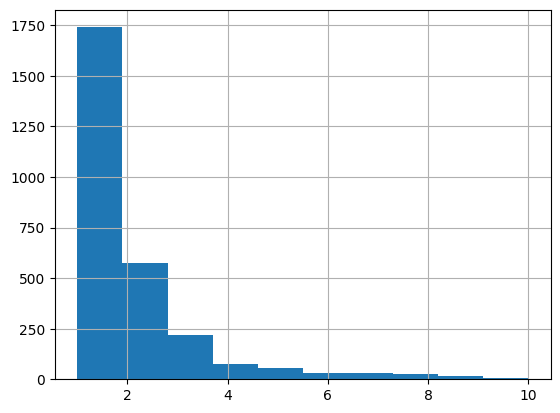

In [133]:
store_data['vlt'].hist()

The graph above follows log-normal distribution. We will generate it that way.

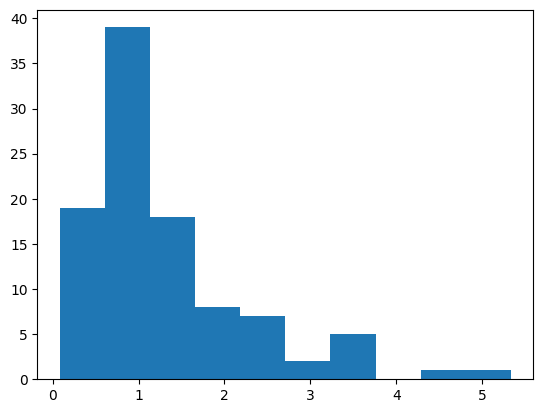

In [71]:
data = np.random.lognormal(mean=0.1, sigma=0.7, size=100)
_ = plt.hist(data)

In [72]:
sku_cols = [c for c in demand.columns if c not in ['id', 'Date']]
init_stock = demand[sku_cols].head(7).sum(axis=0)
vlt = np.ceil(np.random.lognormal(mean=0.1, sigma=0.7, size=len(sku_cols))).astype(int)

store_info = pd.DataFrame({
    'SKU': sku_cols,
    'init_stock': init_stock.values,
    'vlt': vlt
})

In [73]:
store_info

,SKU,init_stock,vlt
0,HOBBIES_1_004_CA_2_evaluation,26,2
1,HOBBIES_1_008_CA_2_evaluation,58,1
2,HOBBIES_1_014_CA_2_evaluation,9,1
3,HOBBIES_1_015_CA_2_evaluation,45,2
4,HOBBIES_1_016_CA_2_evaluation,28,1
...,...,...,...
95,HOUSEHOLD_1_249_CA_2_evaluation,12,2
96,HOUSEHOLD_1_262_CA_2_evaluation,30,2
97,HOUSEHOLD_1_268_CA_2_evaluation,6,1
98,HOUSEHOLD_1_275_CA_2_evaluation,21,2


In [74]:
store_info.to_csv('../processed/wm2/sku100.store_info.csv', index=False)